In [1]:
import scarf
import scarf.plotting as splt

scarf.set_verbosity("WARNING")

scarf.fetch_dataset(
    "tenx_5K_pbmc_rnaseq",
    save_path="scarf_datasets",
    as_zarr=True,
)
ds = scarf.DataStore(
    "scarf_datasets/tenx_5K_pbmc_rnaseq/data.zarr",
    nthreads=4,
    min_features_per_cell=10,
)

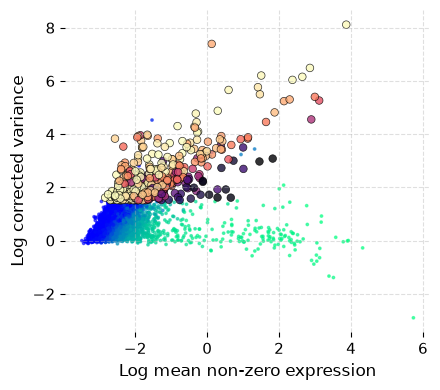

In [2]:
ds.filter_cells(attrs=["RNA_nCounts"], highs=[15000], lows=[1000], reset_previous=True)
ds.mark_hvgs(min_cells=20, top_n=500)
ds.make_graph(feat_key="hvgs", k=11, dims=15)
ds.run_umap(n_epochs=150, parallel=True)

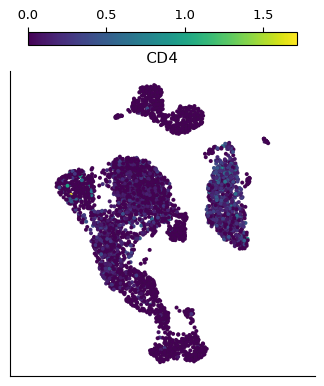

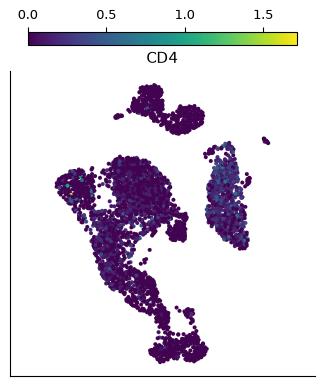

In [3]:
imputed_cd4 = ds.get_imputed(feature_name="CD4", t=2)
ds.cells.insert("CD4_imputed", imputed_cd4, overwrite=True)
splt.embedding(ds, layout_key="RNA_UMAP", color_by="CD4", show=False).figure

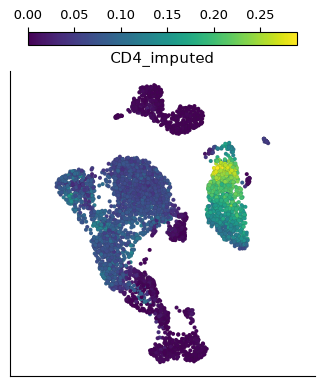

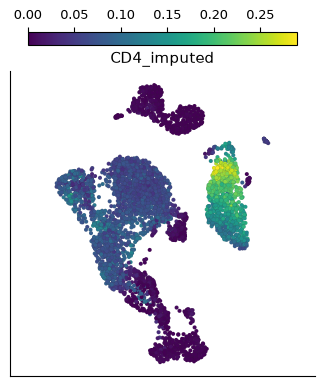

In [4]:
splt.embedding(ds, layout_key="RNA_UMAP", color_by="CD4_imputed", show=False).figure